# Adult Census Income: EDA

В этом notebook выполняется exploratory data analysis для очищенного Adult Census Income dataset.

Цель этапа:

- понять распределение целевой переменной;
- изучить числовые и категориальные признаки;
- найти признаки, потенциально связанные с доходом;
- подготовить идеи для feature engineering и preprocessing.

Обучение моделей и feature engineering здесь пока не выполняются.

## Загрузка и базовая очистка

Notebook самодостаточный: он заново загружает локальные файлы из `data`, повторяет базовую очистку и удаляет полные дубликаты.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

In [2]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income",
]

train_raw = pd.read_csv("../data/adult.data", header=None, names=columns)
test_raw = pd.read_csv("../data/adult.test", header=None, names=columns, skiprows=1)

df = pd.concat([train_raw, test_raw], ignore_index=True)

for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].str.strip()

df = df.replace("?", np.nan)
df["income"] = df["income"].str.replace(".", "", regex=False)

df_clean = df.drop_duplicates().reset_index(drop=True)
df_eda = df_clean.fillna("Unknown")

print("Rows before removing duplicates:", len(df))
print("Rows after removing duplicates:", len(df_clean))

df_eda.head()

Rows before removing duplicates: 48842
Rows after removing duplicates: 48790


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


`df_clean` сохраняет пропуски как `NaN`. Для EDA-графиков используем `df_eda`, где пропуски заменены на `Unknown`, чтобы неизвестные категории были видны на графиках.

В финальном ML-пайплайне заполнение пропусков всё равно должно выполняться внутри `sklearn Pipeline`.

## Общий обзор данных

In [3]:
print("Shape:", df_eda.shape)

df_eda.info()

Shape: (48790, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48790 entries, 0 to 48789
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48790 non-null  int64 
 1   workclass       48790 non-null  object
 2   fnlwgt          48790 non-null  int64 
 3   education       48790 non-null  object
 4   education_num   48790 non-null  int64 
 5   marital_status  48790 non-null  object
 6   occupation      48790 non-null  object
 7   relationship    48790 non-null  object
 8   race            48790 non-null  object
 9   sex             48790 non-null  object
 10  capital_gain    48790 non-null  int64 
 11  capital_loss    48790 non-null  int64 
 12  hours_per_week  48790 non-null  int64 
 13  native_country  48790 non-null  object
 14  income          48790 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [4]:
numeric_columns = df_eda.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df_eda.select_dtypes(include="object").columns.tolist()

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical columns: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


In [5]:
df_eda[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,48790.0,38.652798,13.708493,17.0,28.0,37.0,48.00,90.0
fnlwgt,48790.0,189668.999365,105617.231232,12285.0,117555.0,178138.5,237606.25,1490400.0
education_num,48790.0,10.078807,2.570046,1.0,9.0,10.0,12.00,16.0
capital_gain,48790.0,1080.217688,7455.905921,0.0,0.0,0.0,0.00,99999.0
capital_loss,48790.0,87.595573,403.209129,0.0,0.0,0.0,0.00,4356.0
hours_per_week,48790.0,40.425886,12.392729,1.0,40.0,40.0,45.00,99.0


In [6]:
df_eda[categorical_columns].nunique().sort_values(ascending=False)

native_country    42
education         16
occupation        15
workclass          9
marital_status     7
relationship       6
race               5
sex                2
income             2
dtype: int64

Признак `fnlwgt` означает final weight: это технический вес записи в выборке Census, а не характеристика человека вроде возраста или образования. Его можно оставить как числовой признак, но интерпретировать нужно осторожно.

## Распределение целевой переменной

In [7]:
target_distribution = pd.DataFrame({
    "count": df_eda["income"].value_counts(),
    "percent": df_eda["income"].value_counts(normalize=True) * 100,
})

target_distribution

,count,percent
income,,
<=50K,37109,76.058619
>50K,11681,23.941381


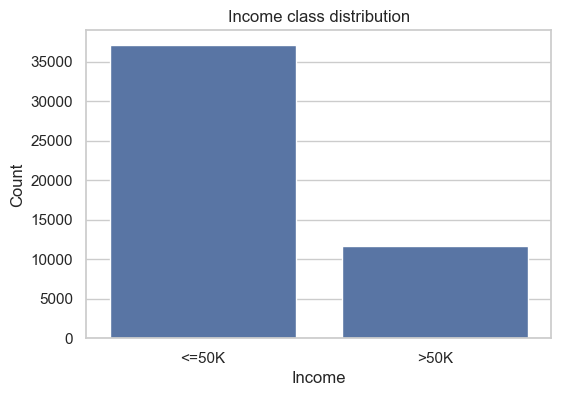

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_eda, x="income", order=["<=50K", ">50K"])
plt.title("Income class distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

Классы несбалансированы: объектов с доходом `<=50K` заметно больше, чем объектов с доходом `>50K`. Поэтому в моделировании нельзя полагаться только на `accuracy`.

## Распределения числовых признаков

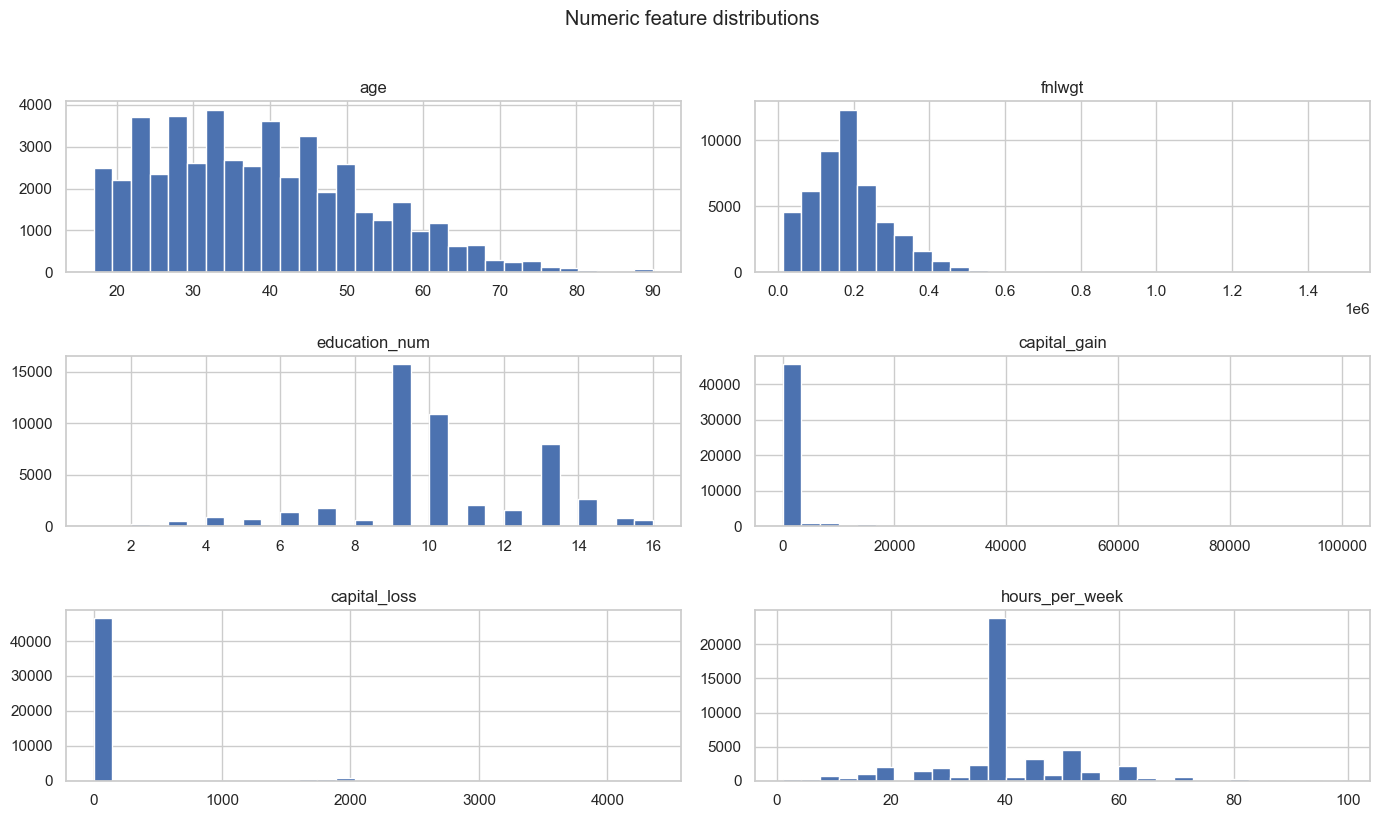

In [9]:
df_eda[numeric_columns].hist(figsize=(14, 8), bins=30)
plt.suptitle("Numeric feature distributions", y=1.02)
plt.tight_layout()
plt.show()

`capital_gain` и `capital_loss` имеют сильный перекос: у большинства объектов значения равны нулю. Это может быть полезно для feature engineering: например, можно добавить признаки факта наличия capital gain/loss.

## Числовые признаки и доход

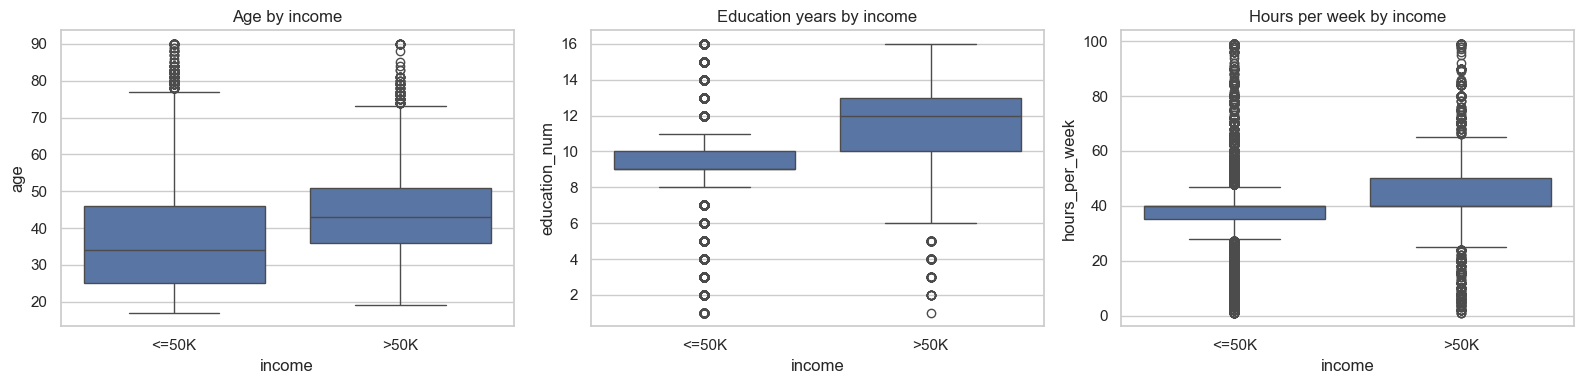

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=df_eda, x="income", y="age", order=["<=50K", ">50K"], ax=axes[0])
axes[0].set_title("Age by income")

sns.boxplot(data=df_eda, x="income", y="education_num", order=["<=50K", ">50K"], ax=axes[1])
axes[1].set_title("Education years by income")

sns.boxplot(data=df_eda, x="income", y="hours_per_week", order=["<=50K", ">50K"], ax=axes[2])
axes[2].set_title("Hours per week by income")

plt.tight_layout()
plt.show()

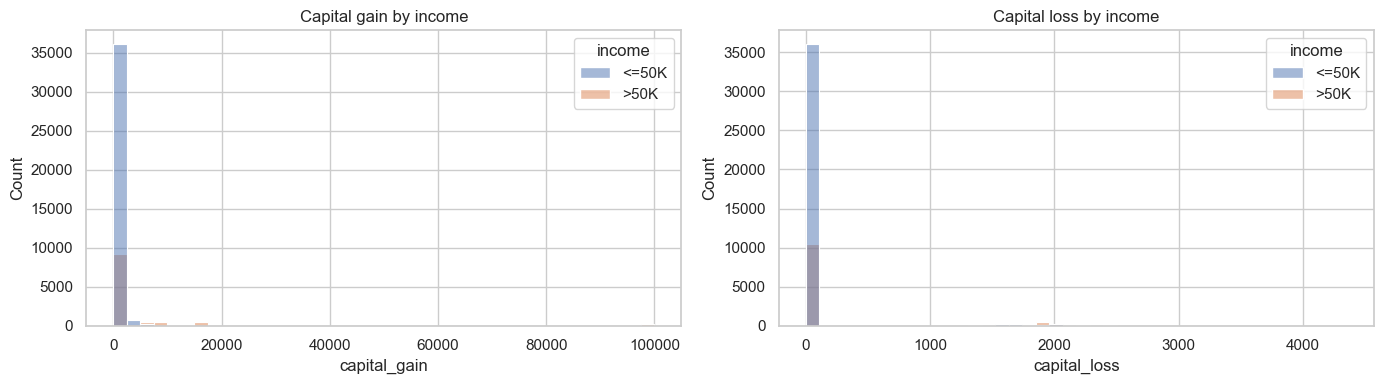

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df_eda, x="capital_gain", hue="income", bins=40, ax=axes[0])
axes[0].set_title("Capital gain by income")

sns.histplot(data=df_eda, x="capital_loss", hue="income", bins=40, ax=axes[1])
axes[1].set_title("Capital loss by income")

plt.tight_layout()
plt.show()

## Категориальные признаки и доход

Для категориальных признаков удобно смотреть долю класса `>50K` внутри каждой категории.

In [12]:
def plot_high_income_rate(column, top_n=None, figsize=(9, 5)):
    data = df_eda.copy()

    if top_n is not None:
        top_categories = data[column].value_counts().head(top_n).index
        data = data[data[column].isin(top_categories)]

    income_rate = pd.crosstab(data[column], data["income"], normalize="index")
    income_rate = income_rate[">50K"].sort_values(ascending=True)

    plt.figure(figsize=figsize)
    sns.barplot(x=income_rate.values, y=income_rate.index)
    plt.title(f">50K share by {column}")
    plt.xlabel("Share of >50K")
    plt.ylabel(column)
    plt.xlim(0, 1)
    plt.show()

    return income_rate.to_frame(name=">50K_share")

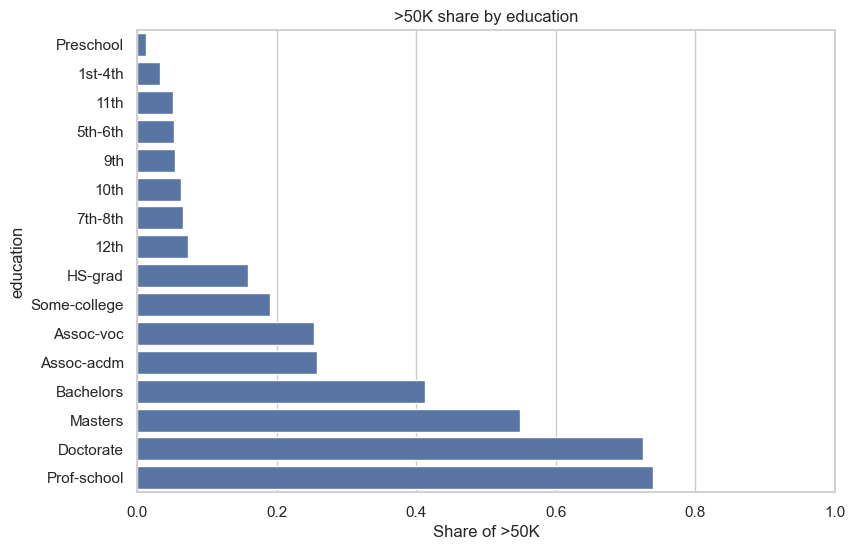

,>50K_share
education,
Preschool,0.012346
1st-4th,0.032653
11th,0.050773
5th-6th,0.053254
9th,0.054233
10th,0.062635
7th-8th,0.064990
12th,0.073282
HS-grad,0.158592


In [13]:
plot_high_income_rate("education", figsize=(9, 6))

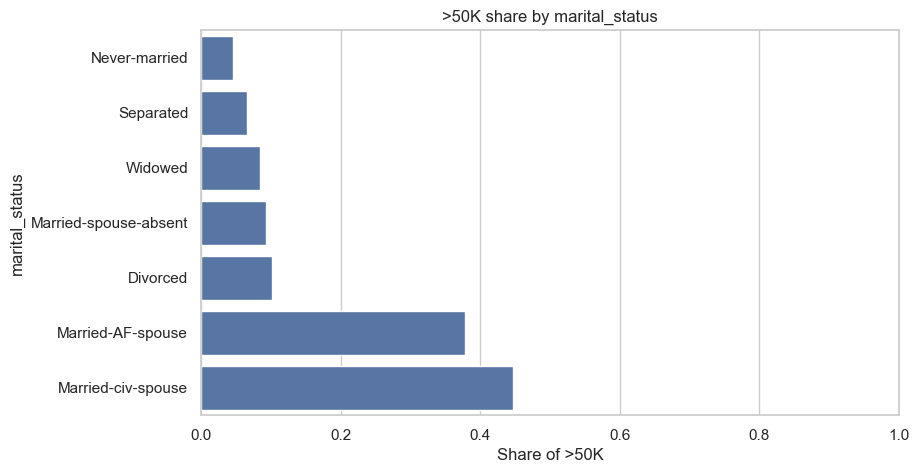

,>50K_share
marital_status,
Never-married,0.045579
Separated,0.064706
Widowed,0.084321
Married-spouse-absent,0.092504
Divorced,0.101207
Married-AF-spouse,0.378378
Married-civ-spouse,0.446124


In [14]:
plot_high_income_rate("marital_status", figsize=(9, 5))

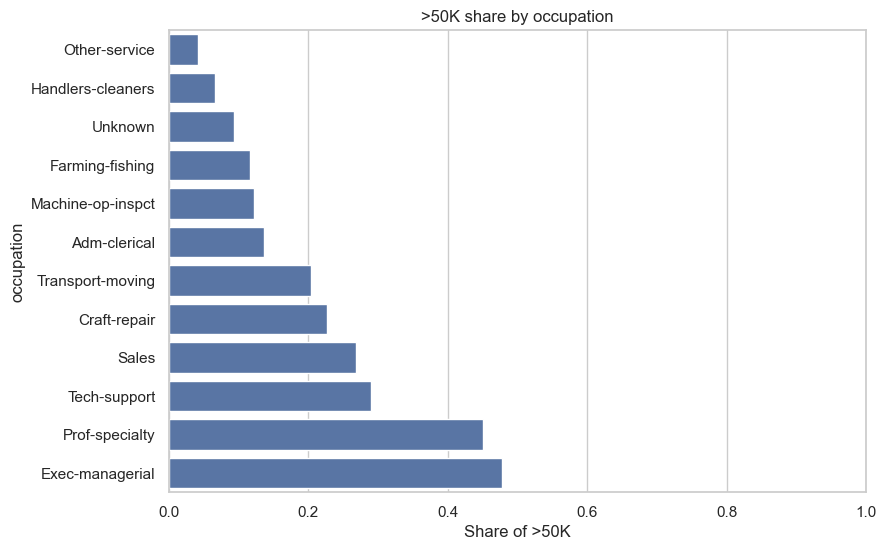

,>50K_share
occupation,
Other-service,0.041472
Handlers-cleaners,0.066634
Unknown,0.094474
Farming-fishing,0.116498
Machine-op-inspct,0.122970
Adm-clerical,0.136996
Transport-moving,0.204246
Craft-repair,0.226483
Sales,0.268133


In [15]:
plot_high_income_rate("occupation", top_n=12, figsize=(9, 6))

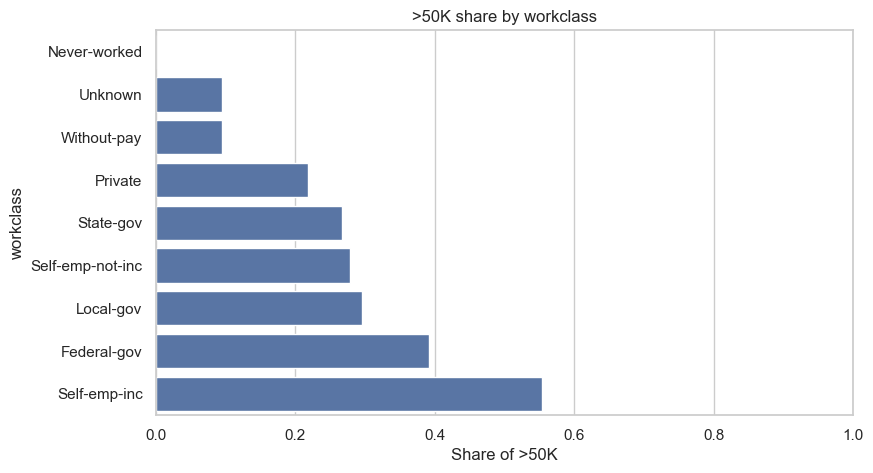

,>50K_share
workclass,
Never-worked,0.000000
Unknown,0.094812
Without-pay,0.095238
Private,0.217986
State-gov,0.267542
Self-emp-not-inc,0.278943
Local-gov,0.295599
Federal-gov,0.391760
Self-emp-inc,0.553719


In [16]:
plot_high_income_rate("workclass", figsize=(9, 5))

Видно, что доля класса `>50K` различается между категориями образования, семейного статуса, профессии и типа занятости. Поэтому категориальные признаки важно кодировать, а не удалять.

## Чувствительные признаки

`sex` и `race` могут быть связаны с целевой переменной, но эти признаки нужно интерпретировать осторожно. Adult Census Income отражает социально-экономические данные 1994 года и может содержать исторические смещения.

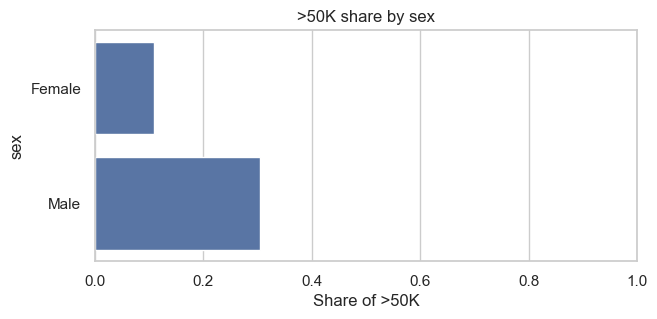

,>50K_share
sex,
Female,0.109360
Male,0.303919


In [17]:
plot_high_income_rate("sex", figsize=(7, 3))

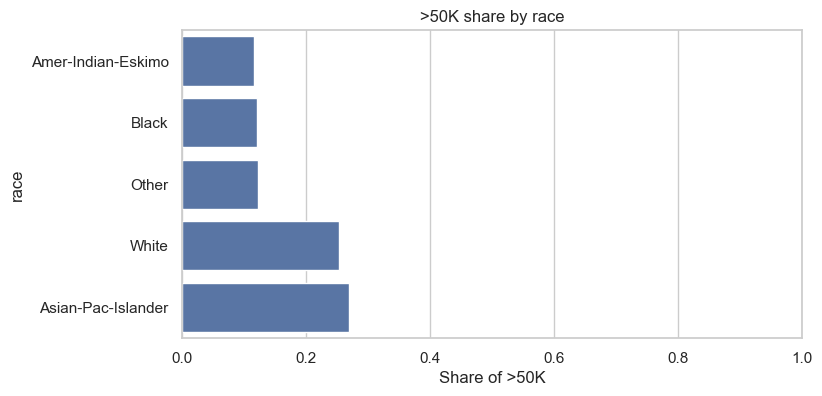

,>50K_share
race,
Amer-Indian-Eskimo,0.117021
Black,0.120863
Other,0.123153
White,0.254135
Asian-Pac-Islander,0.269611


In [18]:
plot_high_income_rate("race", figsize=(8, 4))

## Корреляции числовых признаков

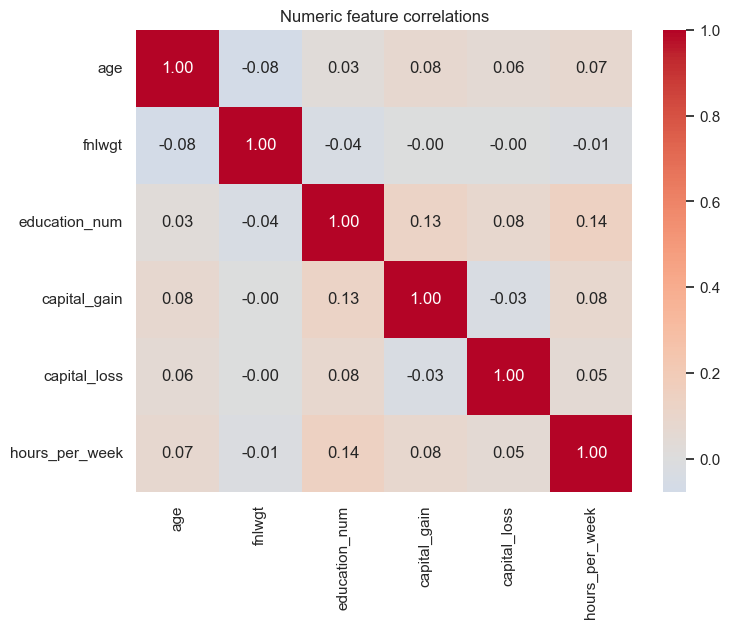

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_eda[numeric_columns].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Numeric feature correlations")
plt.show()

Корреляции между числовыми признаками в целом не выглядят критично высокими. При этом `education` и `education_num` описывают почти одну и ту же информацию: один признак категориальный, другой числовой.

## Предварительные выводы

- В данных есть дисбаланс классов: `<=50K` встречается заметно чаще, чем `>50K`.
- Для оценки моделей нужны метрики помимо accuracy: `balanced_accuracy`, `precision`, `recall`, `f1`, `roc_auc`.
- Числовые признаки имеют разные масштабы, поэтому для Logistic Regression и KNN понадобится scaling.
- Категориальные признаки важны, поэтому их нужно кодировать через OneHotEncoder.
- `capital_gain` и `capital_loss` сильно скошены и часто равны нулю; это хорошая основа для простого feature engineering.
- `age`, `education`, `occupation`, `marital_status`, `hours_per_week` и capital-признаки выглядят потенциально полезными для предсказания дохода.
- `fnlwgt` является техническим весом записи, поэтому его интерпретация требует осторожности.